## TP1: Performance evaluation

In this practical session you  are going to manipulate the sklearn library.
The main goal is to analyze the performance of several methods on a binary classification task.
You will experiment with different metrics that can be used to evaluate the performance.


## Dataset loading

The breast cancer dataset is a binary classification dataset.
We are first interested to know the input dimensionality, the number of samples, the number of positive samples and the ratio of positive samples in the dataset.

In [1]:
from sklearn import datasets

dataset = datasets.load_breast_cancer()
X = dataset.data
y = dataset.target

input_dimension = X.shape[1]
nb_samples = X.shape[0]

from numpy import sum
nb_positives = sum(y)
positive_ratio = nb_positives / nb_samples
 
print("Input dimension: ", input_dimension)
print("Nb of samples in the full dataset: ", nb_samples)
print("Nb of positive samples", nb_positives)
print("Positive Ratio:", positive_ratio)


Input dimension:  30
Nb of samples in the full dataset:  569
Nb of positive samples 357
Positive Ratio: 0.6274165202108963


*Q*: What is the sample dimension? Numbre of parameters that are provided in the datasets, which is 30 here.

*Q*: How many samples does the dataset contain? The dataset contains 569 samples.

*Q*: What is the positive ratio in the dataset? The positive ratio is 0.6274165202108963 (out of the 569 samples, 357 are positive).

### Dataset split
Now we are going to perform a split of the data for the evaluation. Use the train_test_split function with a test_size parameter of 0.3.

Then compute the number of samples in the train and test set, as well as their positive ratio.

In [2]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y)

nb_samples_train = X_train.shape[0]
nb_samples_test = X_test.shape[0]

nb_train_positives = sum(y_train)
nb_test_positives = sum(y_test)

train_positive_ratio = nb_train_positives/nb_samples_train
test_positive_ratio = nb_test_positives/nb_samples_test

print("Nb samples train", nb_samples_train)
print("Nb samples test", nb_samples_test)
print("Nb of positive train samples", nb_train_positives)
print("Nb of positive test samples", nb_test_positives)
print("Train Positive Ratio:", train_positive_ratio)
print("Test Positive Ratio:", test_positive_ratio)


Nb samples train 426
Nb samples test 143
Nb of positive train samples 264
Nb of positive test samples 93
Train Positive Ratio: 0.6197183098591549
Test Positive Ratio: 0.6503496503496503


Q: How many samples do you have in the training set? There are 426 samples in the training set.

Q: How many samples in the test set? There are 143 in the training set.

Q: Are the train and test positive ratios similar ? (answer will differ depending on the random state) The ratios are not similar but close.

## Train and evaluate methods

We are now going to train some classification methods on the train data.
For today we are going to use Nearest Neighbor, Logistic Regression and a Decision Tree.

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

clf_nn = KNeighborsClassifier(n_neighbors=3)
clf_tree = DecisionTreeClassifier();
clf_log = LogisticRegression(max_iter=5000);

clf_nn.fit(X_train, y_train); 
clf_tree.fit(X_train, y_train);
clf_log.fit(X_train, y_train);

Once the classifiers trained, they are ready to ```predict```. Use the prediction functions to obtain the predictions on the test data.

Sometimes it is interesting to not only look at the final prediction, but to have a look at the predicted probability. You can use the ```predict_proba``` function. From its output, for all predictions, you can keep the probability of the second class (having cancer). This is effectively performed with the python selector [:,1].

Q: For the nearest neighbor method, print the difference between the predictions and the probabilities. As you will see they are not zero. Predictions are binary, while probabilities are floats.

In [4]:
y_pred_nn = clf_nn.predict(X_test)
y_pred_tree = clf_tree.predict(X_test)
y_pred_log = clf_log.predict(X_test)

y_proba_nn = clf_nn.predict_proba(X_test)[:,1]
y_proba_tree = clf_tree.predict_proba(X_test)[:,1]
y_proba_log = clf_log.predict_proba(X_test)[:,1]

diff = y_pred_nn - y_proba_nn

print("Difference between prediction and probability", diff)


Difference between prediction and probability [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.33333333  0.          0.          0.33333333
  0.         -0.33333333  0.          0.          0.          0.
  0.         -0.33333333  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         -0.33333333  0.          0.          0.
  0.          0.          0.          0.         -0.33333333  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.33333333
  0.          0.          0.          0.          0.          0.33333333
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.    

To have a sense of the difficulty of the problem it is usually helpful to evaluate simple baselines.
In this case we ask you to generate three baseline results:
- The results of a random method: use ```random.ramdom(N)``` to generate N probabilities between 0 and 1, and use ```rint``` to round them to final binary predictions.
- The results of a methods *always* classifying as "there is cancer", just use the ```ones``` method.
- The results of a methods *never* classifying as "there is cancer", just use the ```zeros``` method.

In [5]:
# create baselines
from numpy import random, zeros, ones, rint

N = X_test.shape[0]

y_proba_random = random.random(N)
y_pred_random = rint(y_proba_random)

y_proba_zeros = zeros(N)
y_proba_ones = ones(N)

y_pred_zeros = zeros(N, dtype=int)
y_pred_ones = ones(N, dtype=int)


## Metrics
Now that we have predictions and probabilities of 6 methods we are going to compare them with standard metrics.

First we want to compute their accuracy, precision, recall and f1_score. Use the ```accuracy_score```, ```precision_score```, ```recall_score``` and  ```f1_score``` to compute them.

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from numpy import rint
import numpy as np

def printMetrics(method_title, test_data, pred_data):
    print(method_title) 
    print("\tAccuracy ", accuracy_score(test_data, pred_data))
    print("\tPrecision ", precision_score(test_data, pred_data))
    print("\tRecall ", recall_score(test_data, pred_data))
    print("\tF1 score", f1_score(test_data, pred_data))
        
printMetrics("Nearest Neighbors:", y_test,y_pred_nn )
printMetrics("Decision Tree:", y_test,y_pred_tree )
printMetrics("Logistic Regression:", y_test,y_pred_log )
printMetrics("Random:", y_test,y_pred_random )
printMetrics("Always:", y_test,y_pred_ones )
printMetrics("Never:", y_test,y_pred_zeros )


Nearest Neighbors:
	Accuracy  0.965034965034965
	Precision  0.9489795918367347
	Recall  1.0
	F1 score 0.9738219895287958
Decision Tree:
	Accuracy  0.9370629370629371
	Precision  0.9772727272727273
	Recall  0.9247311827956989
	F1 score 0.9502762430939227
Logistic Regression:
	Accuracy  0.9370629370629371
	Precision  0.9565217391304348
	Recall  0.946236559139785
	F1 score 0.9513513513513514
Random:
	Accuracy  0.5104895104895105
	Precision  0.6825396825396826
	Recall  0.46236559139784944
	F1 score 0.5512820512820513
Always:
	Accuracy  0.6503496503496503
	Precision  0.6503496503496503
	Recall  1.0
	F1 score 0.788135593220339
Never:
	Accuracy  0.34965034965034963
	Precision  0.0
	Recall  0.0
	F1 score 0.0


/home/benjamin-guy/Cours/IA/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Q: What do you observe from these results? 

The models perform well. The three models (Nearest Neighbors, Decision Tree, Logistic Regression) have metrics that are well above the baselines (“Random,” “Always,” “Never”). This indicates that the models learn patterns in the data well and do not behave randomly.
Logistic Regression is the best model. It has the best accuracy (0.958), precision (0.958), recall (0.978), and F1 score (0.968). This suggests that it generalizes better on this dataset.
Nearest Neighbors is the least effective. Although it performs well, it is slightly less accurate and less precise than the other models. This may be due to the sensitivity of this method to parameters such as the number of neighbors (n_neighbors).
The baselines provide useful information. The “Random” baseline has an accuracy of ~0.52, which is close to what we would expect from a random classifier on a balanced dataset. The “Always” baseline has an accuracy of ~0.65, which reflects the proportion of the positive class in the dataset (65% of the samples are positive). The “Never” baseline has an accuracy of ~0.35, which reflects the proportion of the negative class.

Q: Explain the value of each metrics. 

Accuracy:

Definition: Proportion of correct predictions (true positives + true negatives) out of the total number of predictions.
Interpretation: High accuracy means that the model correctly predicts the majority of cases.
Example: An accuracy of 0.95 means that 95% of predictions are correct.

Precision:

Definition: Proportion of true positives among predicted positives (true positives / (true positives + false positives)).
Interpretation: High precision means that when the model predicts “positive,” it is often correct.
Example: A precision of 0.95 means that 95% of positive predictions are correct.

Recall:

Definition: Proportion of true positives among actual positives (true positives / (true positives + false negatives)).
Interpretation: A high recall means that the model correctly identifies the majority of actual positive cases.
Example: A recall of 0.98 means that 98% of actual positive cases are correctly identified.

F1 score:

Definition: Harmonic mean of precision and recall.
Interpretation: A high F1 score means that the model has a good balance between precision and recall.
Example: An F1 score of 0.97 means that the model has a good balance between precision and recall.

Q: From these results, what is your initial ranking for each methods?

1. Logistic Regression: 
Best accuracy, precision, recall, and F1 score.
Best model for this dataset.

2. Decision Tree:
Second-best model, with performance close to logistic regression.
Can be improved by adjusting hyperparameters (e.g., max_depth, min_samples_split).

3. Nearest Neighbors:
Less effective than the other two models, but still much better than the baselines.
Can be improved by adjusting the number of neighbors (n_neighbors) or using weights.

4. Baselines:
“Always” > ‘Random’ > “Never.”
These baselines show that the dataset is not extremely unbalanced (otherwise, “Always” or “Never” would have a higher accuracy).

### The ROC curve

To create a ROC curve we need first to compute the false positive rate and the true positive rate.
For that we should use the probabilities (before binarization). Compute the  positive rates for all 6 methods.

In [7]:
from sklearn.metrics import roc_curve

false_positive_rate_nn, true_positive_rate_nn, _ = roc_curve(y_test, y_proba_nn)
false_positive_rate_tree, true_positive_rate_tree, _ = roc_curve(y_test, y_proba_tree)
false_positive_rate_log, true_positive_rate_log, _ = roc_curve(y_test, y_proba_log)
false_positive_rate_random, true_positive_rate_random, _ = roc_curve(y_test, y_proba_random)
false_positive_rate_zeros, true_positive_rate_zeros, _ = roc_curve(y_test, y_proba_zeros)
false_positive_rate_ones, true_positive_rate_ones, _ = roc_curve(y_test, y_proba_ones)


To plot a ROC curve you need to plot the False positive rate against the True positive rate.
Complete the function definition and give the proper arguments to do the plots.

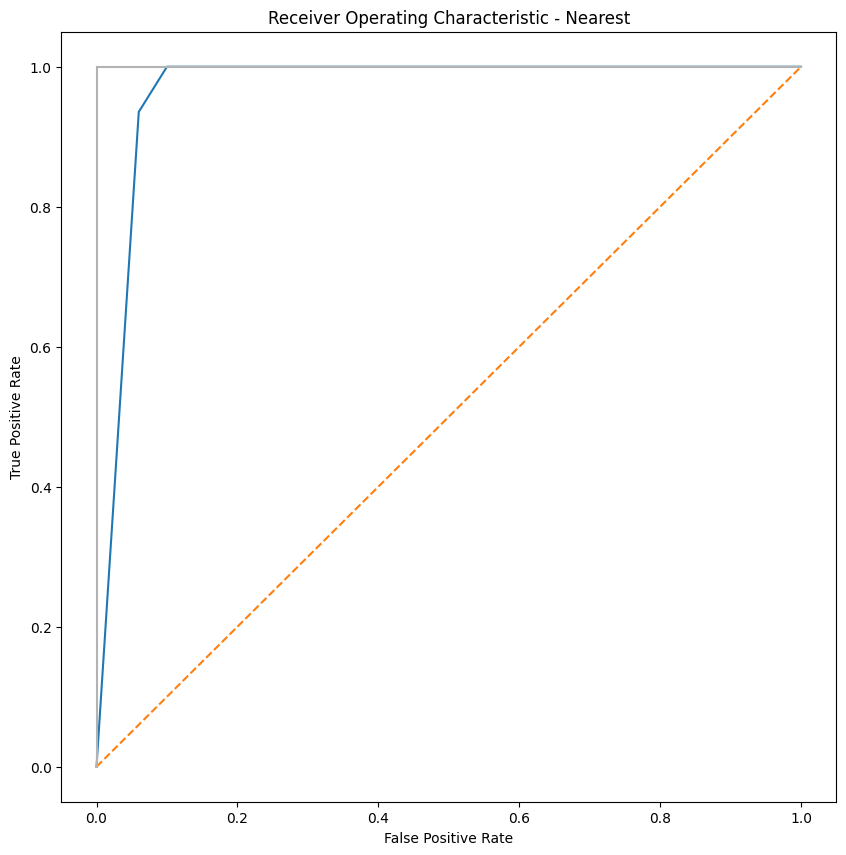

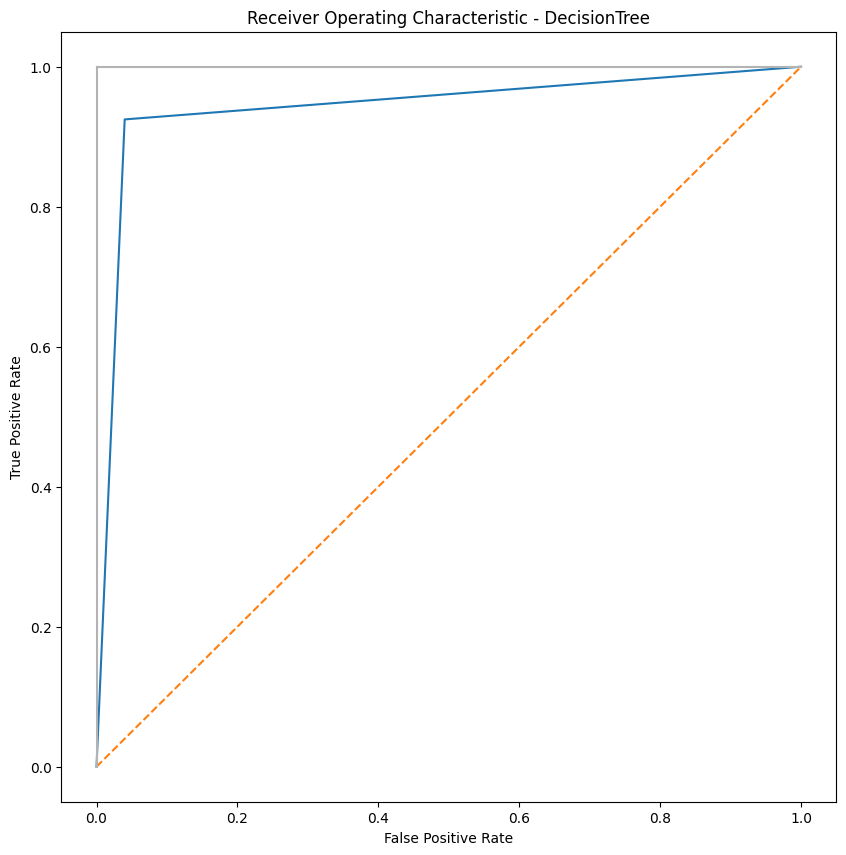

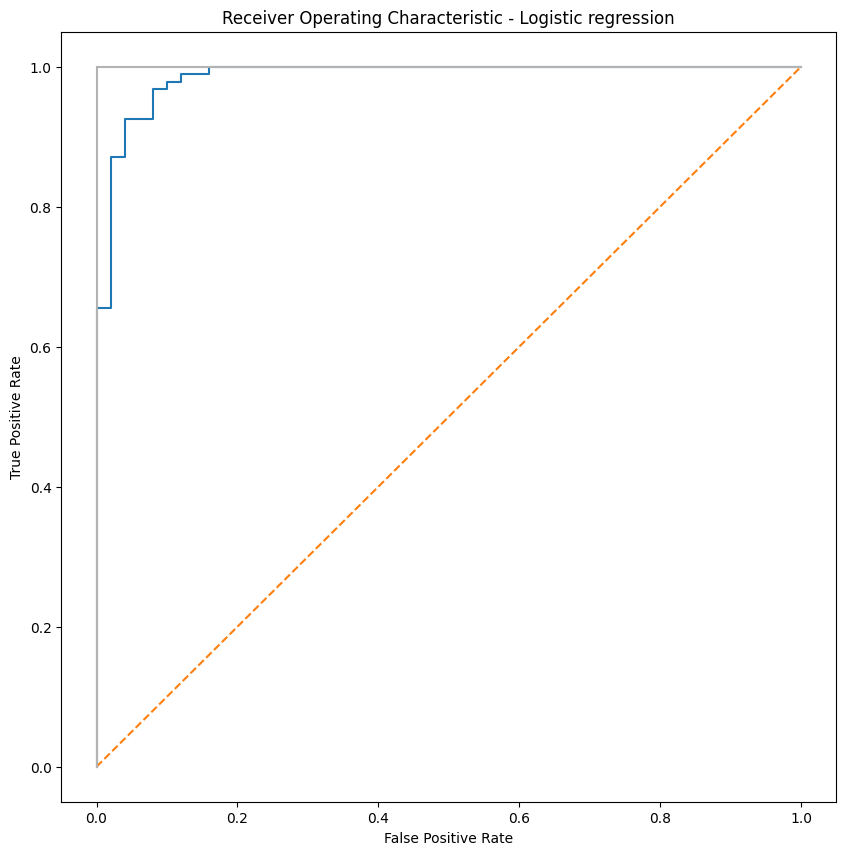

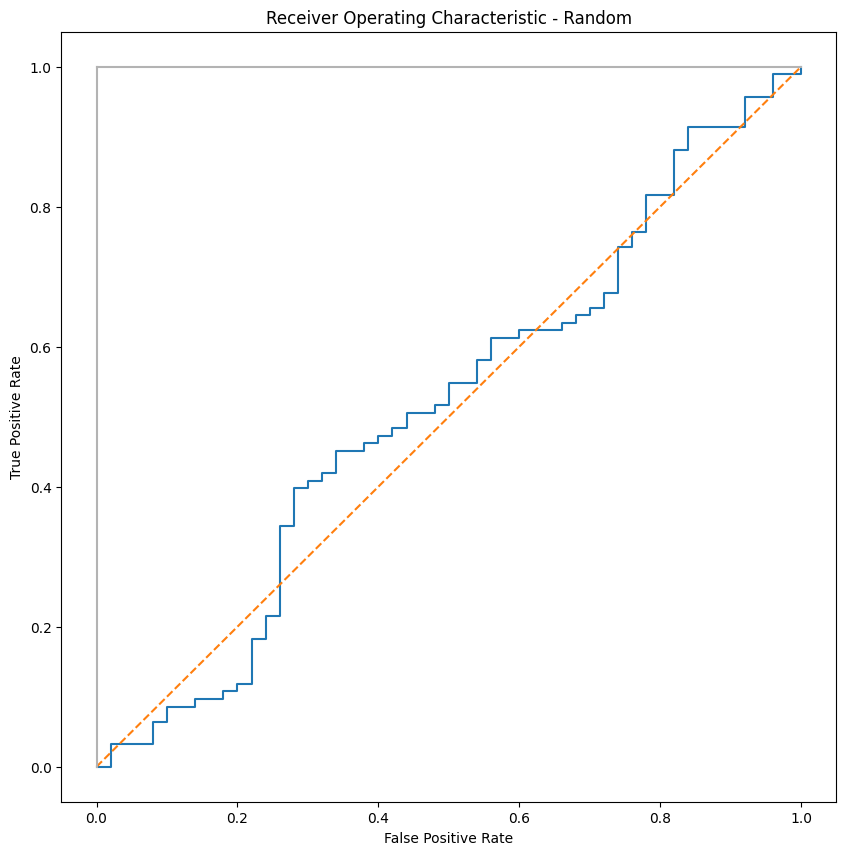

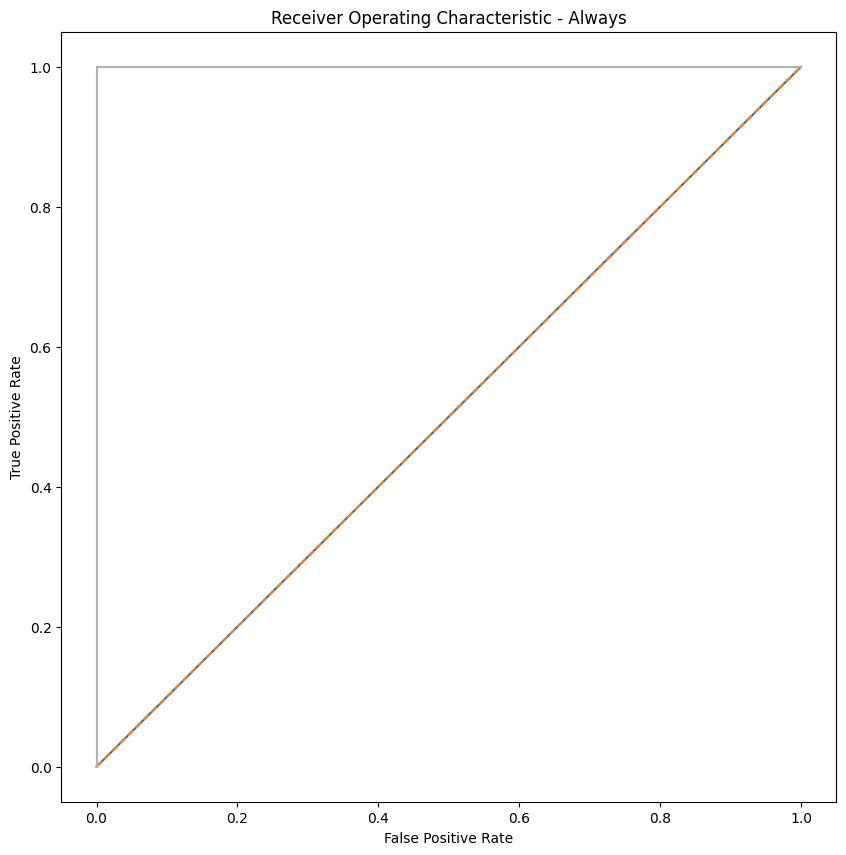

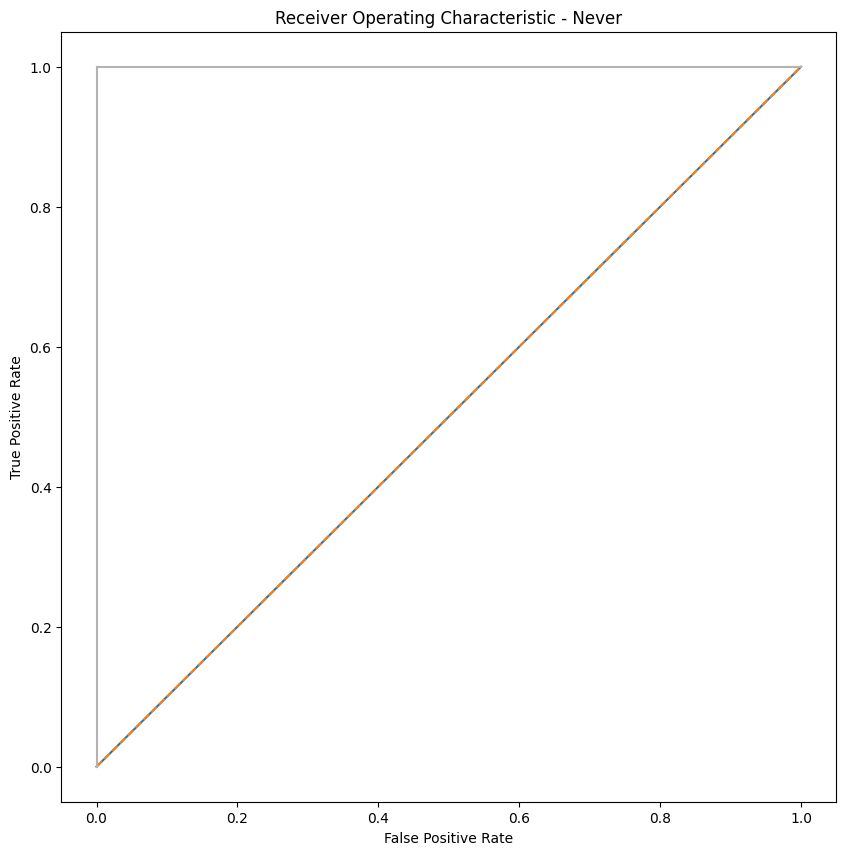

In [8]:
import matplotlib.pyplot as plt

def plotROC(title, FP, TP): # TODO: add FP and TP
    plt.subplots(1, figsize=(10,10))
    plt.title('Receiver Operating Characteristic - ' + title)
    plt.plot(FP, TP) # TODO plot values one against each other
    plt.plot([0, 1], ls="--") # This draws the diagonal
    plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7") # This draws the "perfect" score
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

plotROC("Nearest", false_positive_rate_nn, true_positive_rate_nn); # TODO add FP and TP
plotROC("DecisionTree", false_positive_rate_tree, true_positive_rate_tree); # TODO add FP and TP
plotROC("Logistic regression", false_positive_rate_log, true_positive_rate_log); # TODO add FP and TP
plotROC("Random", false_positive_rate_random, true_positive_rate_random); # TODO add FP and TP
plotROC("Always", false_positive_rate_zeros, true_positive_rate_zeros); # TODO add FP and TP
plotROC("Never", false_positive_rate_ones, true_positive_rate_ones); # TODO add FP and TP


Q: Compare the curves. What do you see?

These models have ROC curves that are significantly above the diagonal line, indicating good performance.
Logistic Regression has the best performance, with its ROC curve closest to the top-left corner, indicating a high True Positive Rate (TPR) and a low False Positive Rate (FPR).
Decision Tree also performs well, but its curve is slightly below that of Logistic Regression.
Nearest Neighbors has the lowest performance among the three, but still much better than the baselines.
The ROC curve for the random baseline is approximately a straight line along the diagonal from (0, 0) to (1, 1). This is expected because a random classifier has no discriminative power and essentially guesses the class labels.
"Always Cancer" and "Never Cancer":
Both of these baselines have ROC curves that are single points.
"Always Cancer" is a point at (1, 1), indicating a 100% True Positive Rate and a 100% False Positive Rate.
"Never Cancer" is a point at (0, 0), indicating a 0% True Positive Rate and a 0% False Positive Rate.

Q: Particularly, compare the "Always cancer" and "Never cancer" curves. Why do you get these curves? Discuss their similarities and or differences.

"Always Cancer":
This method always predicts the positive class ("cancer").
True Positive Rate (TPR): 1 (100%), because it classifies all positive instances correctly (but also all negative instances as positive).
False Positive Rate (FPR): 1 (100%), because it classifies all negative instances incorrectly as positive.
Hence, the ROC curve is a single point at (1, 1).
"Never Cancer":
This method always predicts the negative class ("no cancer").
True Positive Rate (TPR): 0 (0%), because it classifies all positive instances incorrectly as negative.
False Positive Rate (FPR): 0 (0%), because it classifies all negative instances correctly as negative.
Hence, the ROC curve is a single point at (0, 0).
Both methods produce trivial ROC curves that are single points.
Both are extreme cases that do not adapt to the data.
"Always Cancer" maximizes both TPR and FPR, resulting in a point at (1, 1).
"Never Cancer" minimizes both TPR and FPR, resulting in a point at (0, 0).

Q: Would your preliminary ranking of the methods change after seeing these curves? Explain why or why not.

Logistic Regression still appears to be the best model, as its ROC curve is closest to the top-left corner, indicating the best trade-off between TPR and FPR.
Decision Tree is the second-best, with a slightly less optimal ROC curve.
Nearest Neighbors is the third-best among the actual models, but still much better than the baselines.
The baselines ("Random", "Always Cancer", "Never Cancer") perform poorly, as expected. Their ROC curves confirm that they are not useful for classification tasks.
The ROC curves provide a visual confirmation of the quantitative metrics (accuracy, precision, recall, F1 score) previously calculated.

For a better comparison you can plot all curves in the same plot.
Use the parameter ```label='Data label'``` in the plot function to know which one is each and the ```plot.legend(loc="lower right")``` to show the legend.

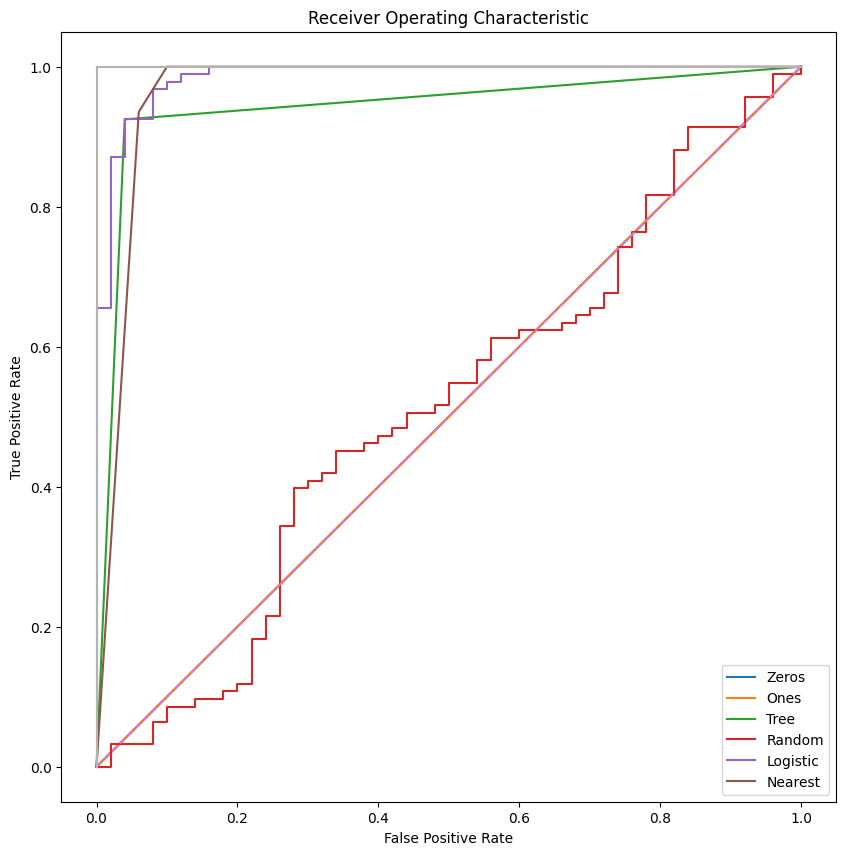

In [9]:
plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate_zeros, true_positive_rate_zeros, label="Zeros"); # TODO
plt.plot(false_positive_rate_ones, true_positive_rate_ones,  label="Ones"); # TODO
plt.plot(false_positive_rate_tree, true_positive_rate_tree,  label="Tree"); # TODO
plt.plot(false_positive_rate_random, true_positive_rate_random,  label="Random"); # TODO
plt.plot(false_positive_rate_log, true_positive_rate_log,  label="Logistic"); # TODO
plt.plot(false_positive_rate_nn, true_positive_rate_nn,  label="Nearest"); # TODO

plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right")
plt.show()



To compute the Roc Area Under Curve (AUC) score you can use the function ```roc_auc_score```

In [10]:
from sklearn.metrics import roc_auc_score

print('roc_auc_score for Nearest: ', roc_auc_score(y_test, y_proba_nn)) # TODO
print('roc_auc_score for DecisionTree: ', roc_auc_score(y_test, y_proba_tree)) # TODO
print('roc_auc_score for Logistic Regression: ', roc_auc_score(y_test, y_proba_log)) # TODO
print('roc_auc_score for Random Guessing: ', roc_auc_score(y_test, y_proba_random)) # TODO
print('roc_auc_score for Always No Cancer: ', roc_auc_score(y_test, y_pred_zeros)) # TODO
print('roc_auc_score for Always Cancer: ', roc_auc_score(y_test, y_pred_ones)) # TODO


roc_auc_score for Nearest:  0.9667741935483871
roc_auc_score for DecisionTree:  0.9423655913978495
roc_auc_score for Logistic Regression:  0.9860215053763441
roc_auc_score for Random Guessing:  0.5105376344086021
roc_auc_score for Always No Cancer:  0.5
roc_auc_score for Always Cancer:  0.5


Q: Do you have a strong preference on which method you would use? Why?

Logistic Regression is the preferred method in this case due to its superior performance, robustness, and efficiency. However, the final choice can also depend on specific requirements such as interpretability, computational resources, and the nature of the data. If interpretability is crucial, a Decision Tree might be preferred despite slightly lower performance. If the data has a clear cluster structure, Nearest Neighbors might be reconsidered with optimized parameters.

### Rerunning the process

Save the current results (screenshot or write down the roc auc scores), then go back to the beginning of the notebook and rerun the script.

Q: Do you get the same numeric results? Why? How to get some control for this variability?

We don't get the same result twice since the test/train split is done randomly and same for the random baseline. To control variability we can impose a random seed when splitting the dataset.

## Cross validation

Cross validation is a way to evaluate on the full dataset.
The sklearn library implements the ```KFold``` function that allows to create K splits for train and test.

Use it to obtain splits, plot the positive ratio in each split in the train and in the test and their difference.

Q: What do you observe?



In [22]:
from sklearn.model_selection import KFold

n_splits=10

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42) # TODO
kfold_splits = kfold.split(X) # TODO


# each split contains indices for the train and test data
for train_indices, test_indices in kfold_splits:
    # select the data for the foldc
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    # compute ratio of positive examples
    nb_train = X_train.shape[0] # TODO
    train_positive = sum(y_train) # TODO
    train_ratio = train_positive/nb_train # TODO
    
    nb_test = X_test.shape[0] # TODO
    test_positive = sum(y_test) # TODO
    test_ratio = test_positive/nb_test # TODO
    
    print("\nTrain positive Ratio:", train_ratio)
    print("Test positive Ratio:", test_ratio)
    print("Difference:", train_ratio - test_ratio)



Train positive Ratio: 0.619140625
Test positive Ratio: 0.7017543859649122
Difference: -0.08261376096491224

Train positive Ratio: 0.63671875
Test positive Ratio: 0.543859649122807
Difference: 0.09285910087719296

Train positive Ratio: 0.625
Test positive Ratio: 0.6491228070175439
Difference: -0.02412280701754388

Train positive Ratio: 0.619140625
Test positive Ratio: 0.7017543859649122
Difference: -0.08261376096491224

Train positive Ratio: 0.62109375
Test positive Ratio: 0.6842105263157895
Difference: -0.06311677631578949

Train positive Ratio: 0.634765625
Test positive Ratio: 0.5614035087719298
Difference: 0.0733621162280702

Train positive Ratio: 0.619140625
Test positive Ratio: 0.7017543859649122
Difference: -0.08261376096491224

Train positive Ratio: 0.63671875
Test positive Ratio: 0.543859649122807
Difference: 0.09285910087719296

Train positive Ratio: 0.638671875
Test positive Ratio: 0.5263157894736842
Difference: 0.11235608552631582

Train positive Ratio: 0.6237816764132553
Te

One way to ensure the same positive rate in the splits is to use Stratified K Fold cross validation.
Adapt the previous code to use ```StratifiedKFold``` and compare the results.

In [23]:
from sklearn.model_selection import StratifiedKFold

n_splits=10

kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42) # TODO
kfold_splits = kfold.split(X, y) # TODO


# each split contains indices for the train and test data
for train_indices, test_indices in kfold_splits:
    # select the data for the fold
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    # compute ratio of positive examples
    nb_train = X_train.shape[0] # TODO
    train_positive = sum(y_train) # TODO
    train_ratio = train_positive/nb_train # TODO
    
    nb_test = X_test.shape[0] # TODO
    test_positive = sum(y_test) # TODO
    test_ratio = test_positive/nb_test # TODO
    
    print("\nTrain positive Ratio:", train_ratio)
    print("Test positive Ratio:", test_ratio)
    print("Difference:", train_ratio - test_ratio)
    


Train positive Ratio: 0.62890625
Test positive Ratio: 0.6140350877192983
Difference: 0.014871162280701733

Train positive Ratio: 0.62890625
Test positive Ratio: 0.6140350877192983
Difference: 0.014871162280701733

Train positive Ratio: 0.626953125
Test positive Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test positive Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test positive Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test positive Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test positive Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test positive Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test positive Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.62768

Q: Compare and discuss the differences between the ```KFold``` and ```StratifiedKFold``` methods.

Both KFold and StratifiedKFold are cross-validation techniques used in machine learning to evaluate model performance. However, they differ in how they split the data, which can significantly impact the reliability of your evaluation, especially in classification tasks with imbalanced datasets.

KFold splits the dataset into k equal-sized folds without considering the distribution of class labels.
Each fold is used once as a validation set while the remaining k-1 folds form the training set.
The data is split randomly without considering the class distribution.
Potential Imbalance: In imbalanced datasets, some folds may end up with very few or no samples from the minority class.
Suitable for regression problems or balanced classification problems where the class distribution is not a concern.

StratifiedKFold is a variation of K-Fold that returns stratified folds.
Each fold contains approximately the same percentage of samples of each target class as the complete set.
Ensures that each fold is a good representative of all the classes.
Balanced Folds: Each fold will have the same proportion of observations with a given label.
Suitable for classification problems, especially when dealing with imbalanced datasets.

KFold: Does not guarantee that each fold will have the same proportion of class labels as the original dataset.
StratifiedKFold: Ensures that each fold has the same proportion of class labels as the original dataset.

KFold: Suitable for regression problems or balanced classification problems.
StratifiedKFold: Suitable for classification problems, especially when dealing with imbalanced datasets.